In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/College/CCI/CCI The Hack/Dataset/balanced_emotion_dataset.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.isna().sum()

,0
label,0
tweet,0


In [ ]:
before = len(df)
df = df.drop_duplicates(subset=["tweet"]).reset_index(drop=True)
after = len(df)
print(f"Hapus duplikat: {before - after} baris")

Hapus duplikat: 1738 baris


In [ ]:
print(df.shape)
print()
df.head()

(9612, 2)



,label,tweet
0,anger,"Soal jalan Jatibaru,polisi tidak bisa GERTAK ..."
1,anger,"Sesama cewek lho (kayaknya), harusnya bisa le..."
2,joy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"jalan Jatibaru,bagian dari wilayah Tn Abang.P..."
4,joy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."


In [ ]:
label_counts = df["label"].value_counts().sort_index()
label_ratio = (df["label"].value_counts(normalize=True).sort_index() * 100).round(2)
print("Distribusi label (count):\n", label_counts)
print("\nDistribusi label (%):\n", label_ratio)

Distribusi label (count):
 label
anger    2256
fear     1603
joy      2270
love     1442
sad      2041
Name: count, dtype: int64

Distribusi label (%):
 label
anger    23.47
fear     16.68
joy      23.62
love     15.00
sad      21.23
Name: proportion, dtype: float64


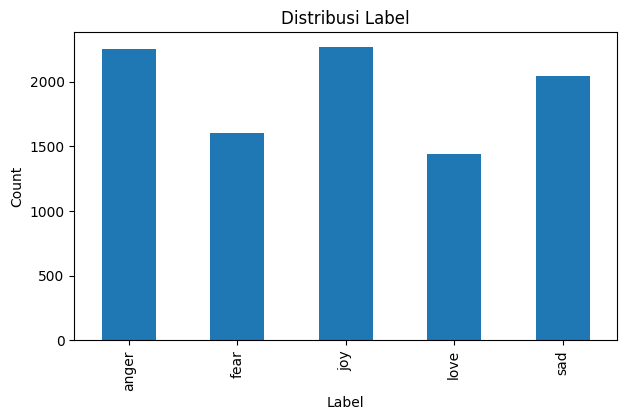

In [ ]:
plt.figure(figsize=(7,4))
label_counts.plot(kind="bar")
plt.title("Distribusi Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [ ]:
stemmer = StemmerFactory().create_stemmer()
base_stop = set(StopWordRemoverFactory().get_stop_words())

negations_keep = {
    "tidak", "tak", "bukan", "nggak", "gak", "ga", "enggak", "belum", "jangan"
}

stopwords_id = base_stop.difference(negations_keep)

extra_fillers = {
    "aja","ajaah","ajaa","dong","deh","nih","sih","mah","lah","yaa","ya","yg","yng","kah",
    "wkwk","wk","hehe","hmm","eh","loh","lho","kok","banget","bgt","bener","beneran",
    "sdh","udh","udah","sudah","gitu","gtu","gituh","gini","gituan"
}
stopwords_id |= extra_fillers

In [ ]:
slang_map = {
    "gak":"tidak", "ga":"tidak", "gk":"tidak", "nggak":"tidak", "enggak":"tidak",
    "klo":"kalau", "kl":"kalau", "utk":"untuk", "dr":"dari", "dgn":"dengan",
    "yg":"yang", "aja":"saja", "jd":"jadi", "sdh":"sudah", "udh":"sudah", "udah":"sudah",
    "bgt":"banget", "sm":"sama", "ttp":"tetap", "tp":"tapi", "tpi":"tapi", "ygnya":"yangnya",
    "km":"kamu", "kmu":"kamu", "sy":"saya", "drpd":"daripada", "dlm":"dalam", "tpn":"tapi"
}

url_pat = re.compile(r"http\S+|www\.\S+")
mention_pat = re.compile(r"@\w+")
hashtag_pat = re.compile(r"#(\w+)")
non_alnum_pat = re.compile(r"[^0-9a-zA-Záéíóúàèìòùçñäëïöüâêîôûãõ\s]")
multi_space_pat = re.compile(r"\s+")

def normalize_repeats(text: str) -> str:
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def apply_slang(tokens):
    return [slang_map.get(t, t) for t in tokens]

def preprocess_text(text: str, do_stem: bool = False) -> str:
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = url_pat.sub(" ", t)
    t = mention_pat.sub(" ", t)
    t = hashtag_pat.sub(r"\1", t)
    t = emoji.replace_emoji(t, replace=" ")
    t = normalize_repeats(t)
    t = non_alnum_pat.sub(" ", t)
    t = re.sub(r"\d+", " ", t)
    t = multi_space_pat.sub(" ", t).strip()

    tokens = t.split()
    tokens = apply_slang(tokens)
    tokens = [w for w in tokens if w not in stopwords_id]
    if do_stem:
        t = " ".join(tokens)
        t = stemmer.stem(t)
        tokens = [w for w in t.split() if w not in stopwords_id]
    return " ".join(tokens)

In [ ]:
tqdm.pandas()

DO_STEM = False
df["clean_text"] = df["tweet"].progress_apply(lambda x: preprocess_text(x, do_stem=DO_STEM))

before = len(df)
df = df[df["clean_text"].str.strip().ne("")].reset_index(drop=True)
print(f"Buang baris kosong setelah preprocessing: {before - len(df)}")
df[["label","tweet","clean_text"]].head(10)

100%|██████████| 9612/9612 [00:01<00:00, 6633.41it/s]

Buang baris kosong setelah preprocessing: 0


,label,tweet,clean_text
0,anger,"Soal jalan Jatibaru,polisi tidak bisa GERTAK ...",soal jalan jatibaru polisi tidak gertak gubern...
1,anger,"Sesama cewek lho (kayaknya), harusnya bisa le...",sesama cewek kayaknya harusnya lebih rasain si...
2,joy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,kepingin gudeg mbarek bu hj amad foto google s...
3,anger,"jalan Jatibaru,bagian dari wilayah Tn Abang.P...",jalan jatibaru bagian wilayah tn abang pengatu...
4,joy,"Sharing pengalaman aja, kemarin jam 18.00 bata...",sharing pengalaman kemarin jam batalin tiket s...
5,anger,"Dari sekian banyak thread yang saya baca, thre...",sekian banyak thread baca thread paling aneh p...
6,joy,Sharing sama teman tuh memang guna bgt. Disaa...,sharing sama teman tuh memang disaat kamu mera...
7,sad,Orang lain kalau pakai ponco itu buat jas huj...,orang kalau pakai ponco buat jas hujan nah pak...
8,anger,"Contoh mereka yang gemar menyudutkan, teriak ...",contoh gemar menyudutkan teriak paling toleran...
9,sad,Pulang sudah H-4 lebaran dilema sekali. Sepert...,pulang h lebaran dilema sekali tidak melakukan...


In [ ]:
# OUT_PATH = "/content/balanced_emotion_dataset_clean.csv"
# df.to_csv(OUT_PATH, index=False)
# print("Saved to:", OUT_PATH)

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

len(X_train), len(X_test)


(8170, 1442)

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_features=100_000,
    sublinear_tf=True,
)

def eval_model(clf, name):
    pipe = Pipeline([
        ("tfidf", tfidf),
        ("clf", clf)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1m = f1_score(y_test, preds, average="macro")
    print(f"[{name}] Accuracy: {acc:.4f} | F1-macro: {f1m:.4f}")
    print(classification_report(y_test, preds))
    return pipe, preds

models = {
    "LinearSVC": LinearSVC(class_weight="balanced"),
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=-1, class_weight="balanced"),
    "MultinomialNB": MultinomialNB()
}

trained = {}
for name, clf in models.items():
    print("="*80)
    pipe, preds = eval_model(clf, name)
    trained[name] = (pipe, preds)


[LinearSVC] Accuracy: 0.7427 | F1-macro: 0.7441
              precision    recall  f1-score   support

       anger       0.76      0.76      0.76       338
        fear       0.78      0.78      0.78       241
         joy       0.78      0.73      0.75       341
        love       0.71      0.81      0.75       216
         sad       0.69      0.66      0.67       306

    accuracy                           0.74      1442
   macro avg       0.74      0.75      0.74      1442
weighted avg       0.74      0.74      0.74      1442

[LogReg] Accuracy: 0.7413 | F1-macro: 0.7433
              precision    recall  f1-score   support

       anger       0.74      0.79      0.76       338
        fear       0.81      0.77      0.79       241
         joy       0.78      0.70      0.74       341
        love       0.70      0.83      0.76       216
         sad       0.69      0.65      0.67       306

    accuracy                           0.74      1442
   macro avg       0.74      0.75     

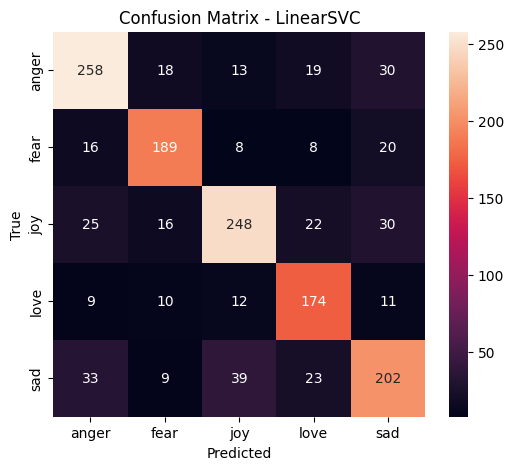

In [ ]:
best_name = "LinearSVC"
best_pipe, best_preds = trained[best_name]

labels_sorted = sorted(pd.unique(y_test))
cm = confusion_matrix(y_test, best_preds, labels=labels_sorted)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

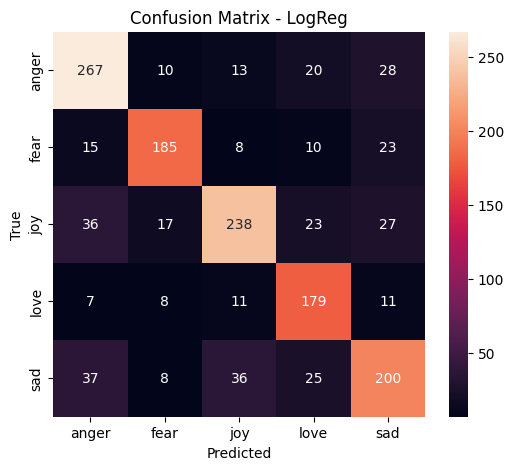

In [ ]:
best_name = "LogReg"
best_pipe, best_preds = trained[best_name]

labels_sorted = sorted(pd.unique(y_test))
cm = confusion_matrix(y_test, best_preds, labels=labels_sorted)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

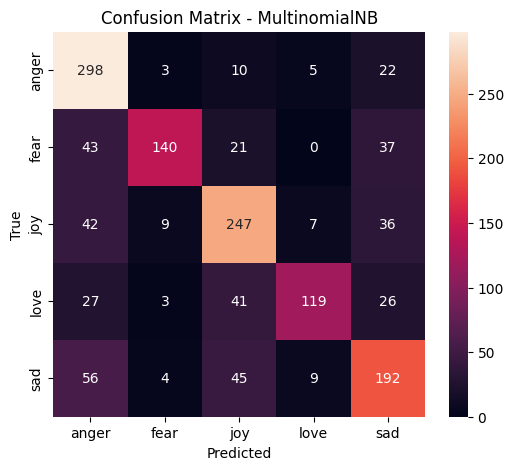

In [ ]:
best_name = "MultinomialNB"
best_pipe, best_preds = trained[best_name]

labels_sorted = sorted(pd.unique(y_test))
cm = confusion_matrix(y_test, best_preds, labels=labels_sorted)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
# import joblib

# joblib.dump(best_pipe, f"/content/{best_name}_tfidf_model.joblib")
# print("Saved model to:", f"/content/{best_name}_tfidf_model.joblib")


In [ ]:
def predict_emotion(texts, pipe=best_pipe):
    if isinstance(texts, str):
        texts = [texts]
    # NOTE: preprocessing ulang sesuai pipeline kamu
    cleaned = [preprocess_text(t, do_stem=DO_STEM) for t in texts]
    return pipe.predict(cleaned)

predict_emotion([
    "aku senang banget hari ini!",
    "kesel deh, pesanan telat terus",
    "takut besok ujian berat"
]).tolist()


['joy', 'anger', 'fear']